# EDA – VN30 Stock Price
Phân tích khám phá dữ liệu giá cổ phiếu VN-30 từ file `vn30_stock_price.csv`.

## 1. Import thư viện & đọc dữ liệu

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
sns.set_theme(style='whitegrid')
pd.options.display.float_format = '{:,.2f}'.format

DATA_FILE = Path('vn30_stock_price.csv')
df = pd.read_csv(DATA_FILE, parse_dates=['date'])
print(f'Shape: {df.shape}')
df.head()

Shape: (96849, 7)


,symbol,date,open,high,low,close,volume
0,ACB,2012-02-06,3.01,3.01,2.98,3.00,137900
1,ACB,2012-02-07,3.01,3.15,3.01,3.14,607800
2,ACB,2012-02-08,3.08,3.22,3.08,3.21,510700
3,ACB,2012-02-09,3.16,3.39,3.15,3.28,1153700
4,ACB,2012-02-10,3.30,3.35,3.22,3.25,393700


## 2. Tổng quan dữ liệu

In [2]:
print('=== Thông tin cơ bản ===')
df.info()
print()
print('=== Phạm vi thời gian ===')
print(f"Từ {df['date'].min().date()}  →  {df['date'].max().date()}")
print(f"Số ngày giao dịch duy nhất: {df['date'].nunique():,}")
print(f"Số mã cổ phiếu: {df['symbol'].nunique()}")
print(f"Danh sách mã: {sorted(df['symbol'].unique())}")

=== Thông tin cơ bản ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96849 entries, 0 to 96848
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   symbol  96849 non-null  object        
 1   date    96849 non-null  datetime64[ns]
 2   open    96849 non-null  float64       
 3   high    96849 non-null  float64       
 4   low     96849 non-null  float64       
 5   close   96849 non-null  float64       
 6   volume  96849 non-null  int64         
dtypes: datetime64[ns](1), float64(4), int64(1), object(1)
memory usage: 5.2+ MB

=== Phạm vi thời gian ===
Từ 2012-02-06  →  2026-04-03
Số ngày giao dịch duy nhất: 3,536
Số mã cổ phiếu: 50
Danh sách mã: ['ACB', 'BCM', 'BID', 'BVH', 'CII', 'CTG', 'DGC', 'DHG', 'DPM', 'EIB', 'FPT', 'GAS', 'GMD', 'GVR', 'HAG', 'HCM', 'HDB', 'HPG', 'IMP', 'KBC', 'KDC', 'LPB', 'MBB', 'MSN', 'MWG', 'NVL', 'PDR', 'PLX', 'PNJ', 'POW', 'PVD', 'PVI', 'REE', 'SAB', 'SBT', 'SHB', 'SSB', 'SSI', 

In [3]:
print('=== Thống kê mô tả ===')
df[['open','high','low','close','volume']].describe().T

=== Thống kê mô tả ===


,count,mean,std,min,25%,50%,75%,max
open,"96,849.00",29.80,27.55,0.78,9.38,19.29,43.44,218.50
high,"96,849.00",30.18,27.90,0.81,9.50,19.52,44.00,220.00
low,"96,849.00",29.40,27.17,0.77,9.26,19.01,42.82,212.20
close,"96,849.00",29.79,27.56,0.80,9.38,19.29,43.41,219.10
volume,"96,849.00","4,237,891.64","8,697,238.36",0.00,"439,058.00","1,301,690.00","4,121,200.00","249,760,712.00"


## 3. Kiểm tra dữ liệu thiếu (Missing Values)

In [4]:
missing = df.isnull().sum()
missing_pct = (df.isnull().mean() * 100).round(2)
missing_df = pd.DataFrame({'missing_count': missing, 'missing_%': missing_pct})
print(missing_df)

# Heatmap thiếu dữ liệu
if missing.sum() > 0:
    fig, ax = plt.subplots(figsize=(10, 4))
    missing_df['missing_%'].plot(kind='bar', ax=ax, color='salmon')
    ax.set_title('Tỷ lệ giá trị thiếu theo cột (%)')
    ax.set_ylabel('%')
    plt.tight_layout()
    plt.show()
else:
    print('Không có giá trị thiếu.')

        missing_count  missing_%
symbol              0       0.00
date                0       0.00
open                0       0.00
high                0       0.00
low                 0       0.00
close               0       0.00
volume              0       0.00
Không có giá trị thiếu.


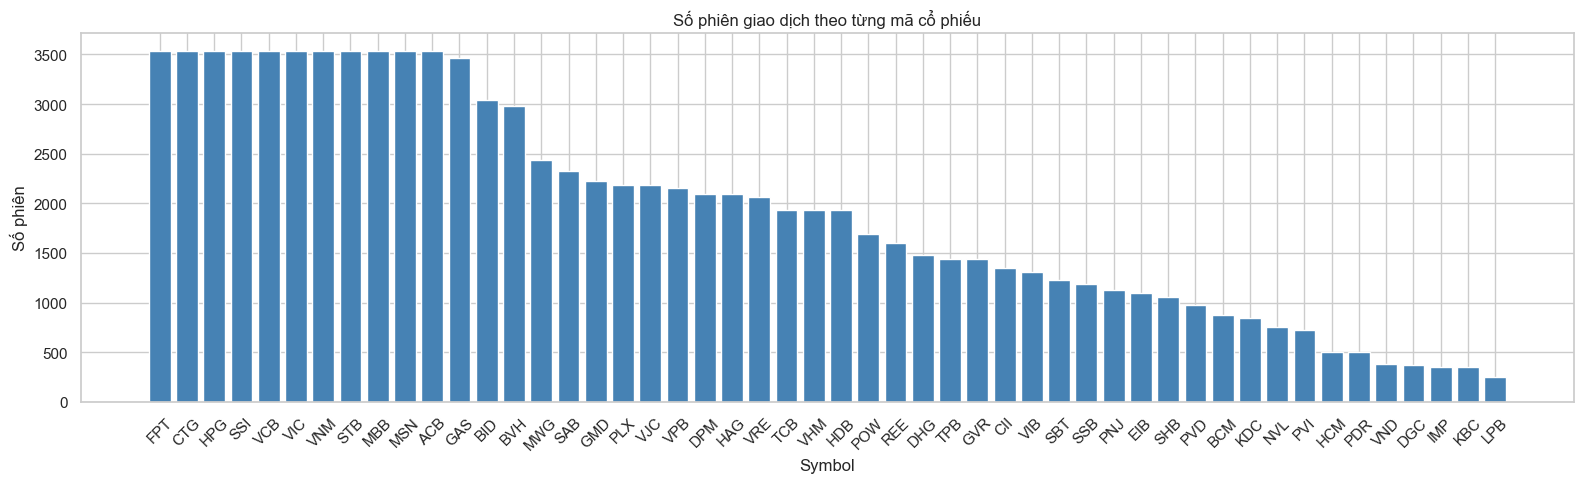

,symbol,sessions
0,FPT,3536
1,CTG,3536
2,HPG,3536
3,SSI,3536
4,VCB,3536
5,VIC,3536
6,VNM,3536
7,STB,3536
8,MBB,3536
9,MSN,3536


In [5]:
# Số phiên giao dịch theo từng mã
sessions = df.groupby('symbol').size().sort_values(ascending=False).reset_index(name='sessions')
fig, ax = plt.subplots(figsize=(16, 5))
ax.bar(sessions['symbol'], sessions['sessions'], color='steelblue')
ax.set_title('Số phiên giao dịch theo từng mã cổ phiếu')
ax.set_xlabel('Symbol')
ax.set_ylabel('Số phiên')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
sessions

## 4. Phân phối giá đóng cửa (Close Price Distribution)

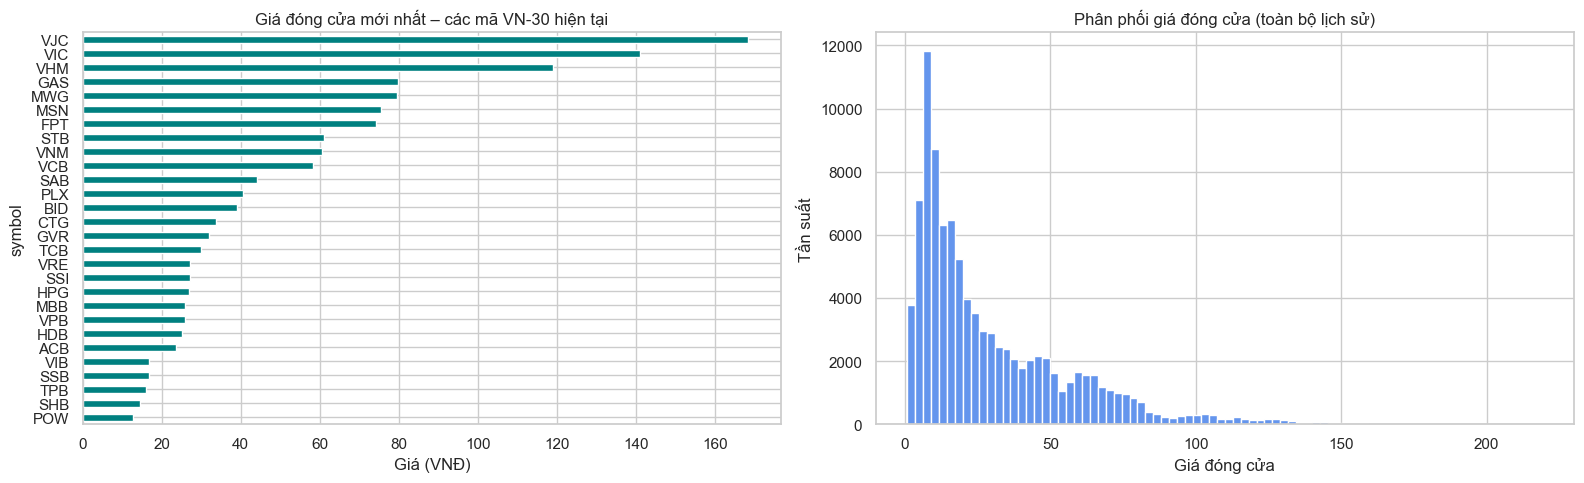

In [6]:
# Phân phối close của các mã hiện tại trong VN-30
current_symbols = df.groupby('symbol')['date'].max()
current_symbols = current_symbols[current_symbols == current_symbols.max()].index.tolist()

latest = df[df['symbol'].isin(current_symbols)].groupby('symbol')['close'].last().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
latest.plot(kind='barh', ax=axes[0], color='teal')
axes[0].set_title('Giá đóng cửa mới nhất – các mã VN-30 hiện tại')
axes[0].set_xlabel('Giá (VNĐ)')

axes[1].hist(df['close'].dropna(), bins=80, color='cornflowerblue', edgecolor='white')
axes[1].set_title('Phân phối giá đóng cửa (toàn bộ lịch sử)')
axes[1].set_xlabel('Giá đóng cửa')
axes[1].set_ylabel('Tần suất')

plt.tight_layout()
plt.show()

## 5. Diễn biến giá theo thời gian

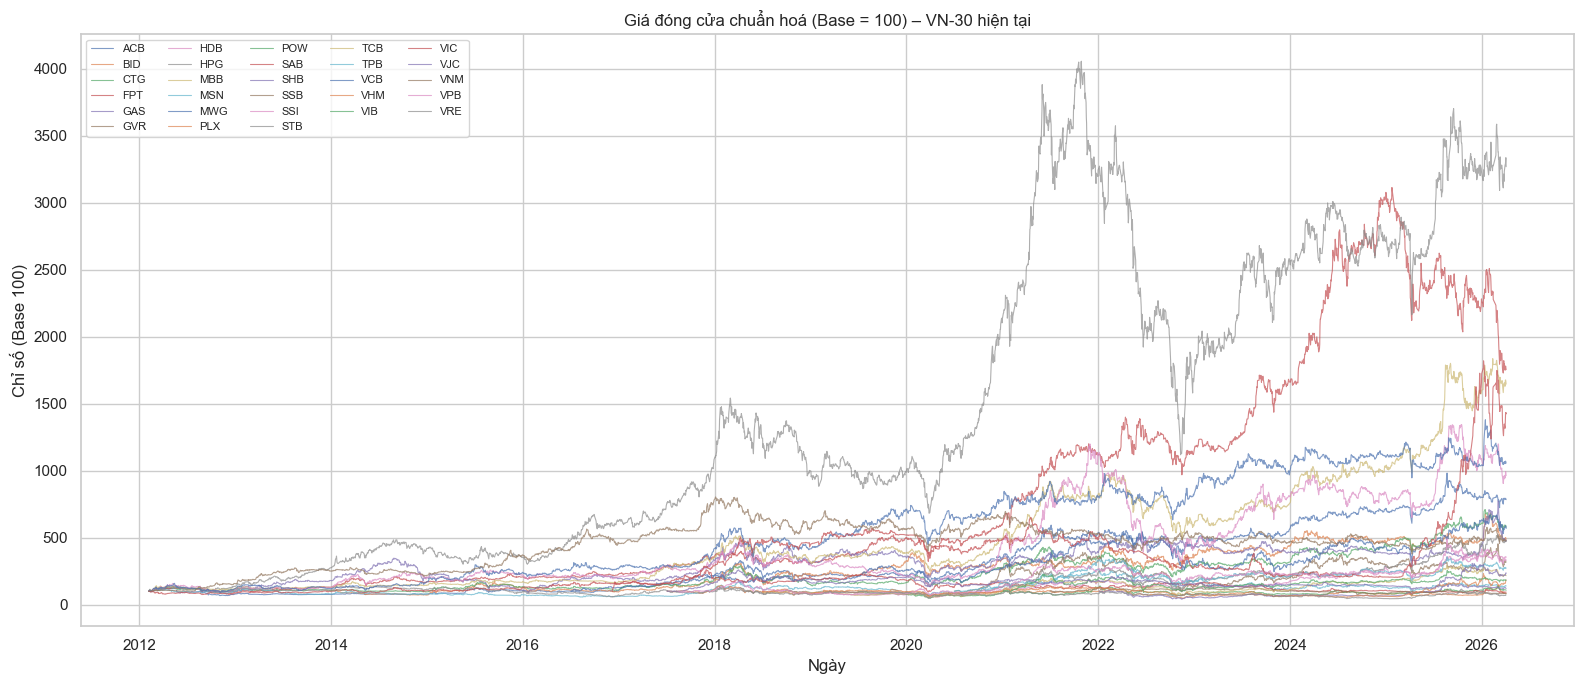

In [7]:
# Vẽ close price chuẩn hoá (base = 100) cho các mã hiện tại
df_curr = df[df['symbol'].isin(current_symbols)].copy()

pivot = df_curr.pivot_table(index='date', columns='symbol', values='close')
# Chỉ giữ những ngày có ít nhất 1 mã có giá
pivot = pivot.dropna(how='all')

# Chuẩn hoá về 100 từ ngày đầu tiên mỗi mã có dữ liệu
normalized = pivot.div(pivot.bfill().iloc[0]) * 100

fig, ax = plt.subplots(figsize=(16, 7))
for sym in normalized.columns:
    ax.plot(normalized.index, normalized[sym], linewidth=0.8, alpha=0.7, label=sym)
ax.set_title('Giá đóng cửa chuẩn hoá (Base = 100) – VN-30 hiện tại')
ax.set_xlabel('Ngày')
ax.set_ylabel('Chỉ số (Base 100)')
ax.legend(ncol=5, fontsize=8, loc='upper left')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

## 6. Phân tích khối lượng giao dịch (Volume)

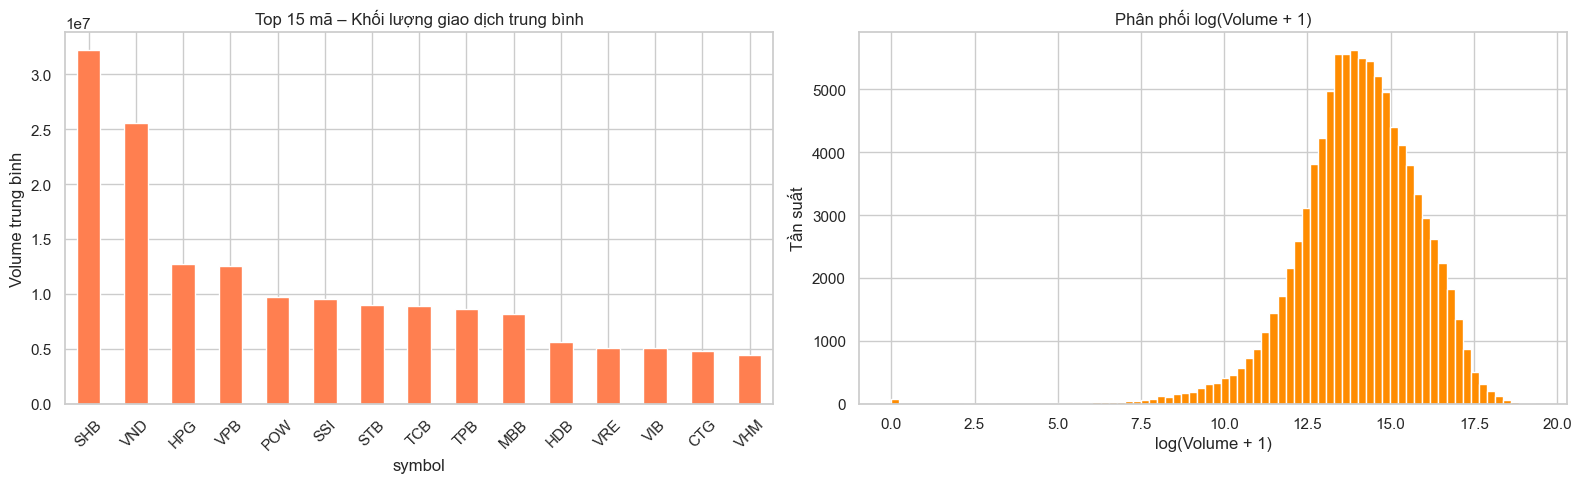

In [8]:
# Top 10 mã có khối lượng trung bình cao nhất
avg_vol = df.groupby('symbol')['volume'].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
avg_vol.head(15).plot(kind='bar', ax=axes[0], color='coral')
axes[0].set_title('Top 15 mã – Khối lượng giao dịch trung bình')
axes[0].set_ylabel('Volume trung bình')
axes[0].tick_params(axis='x', rotation=45)

# Phân phối khối lượng (log scale)
axes[1].hist(np.log1p(df['volume'].dropna()), bins=80, color='darkorange', edgecolor='white')
axes[1].set_title('Phân phối log(Volume + 1)')
axes[1].set_xlabel('log(Volume + 1)')
axes[1].set_ylabel('Tần suất')

plt.tight_layout()
plt.show()

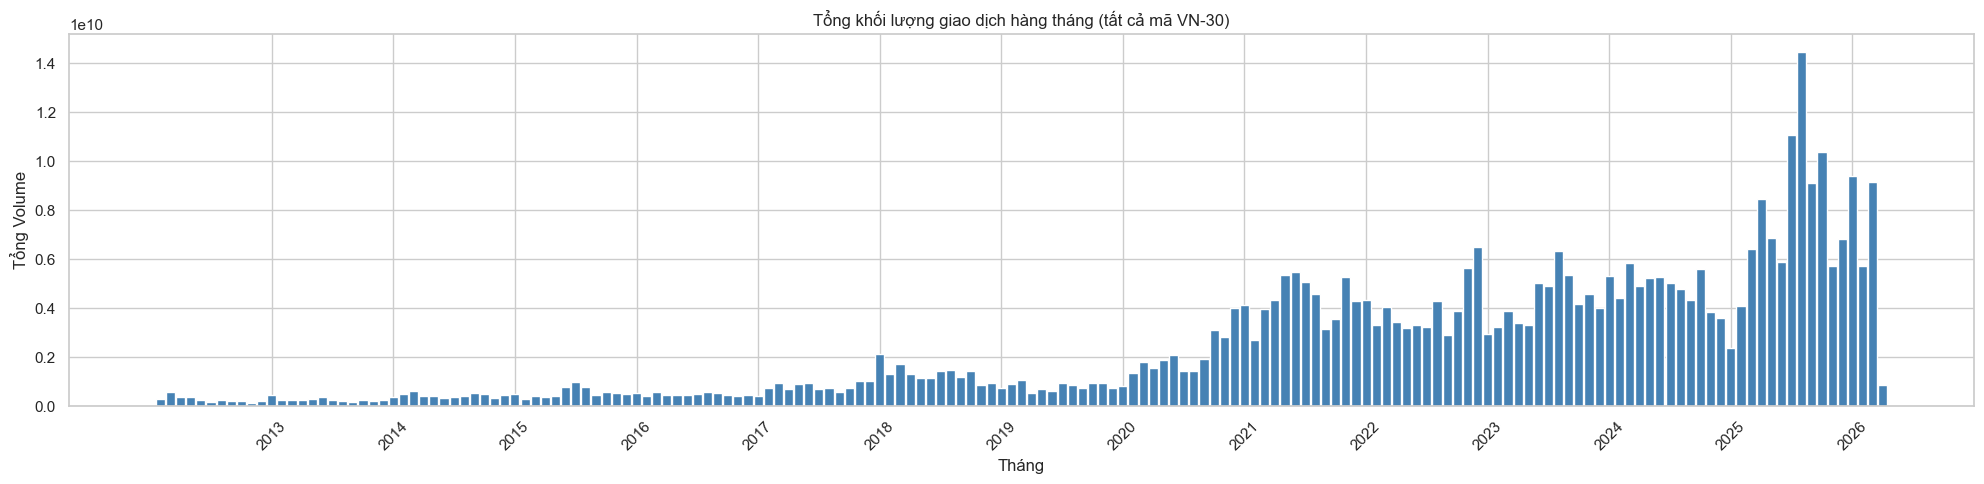

In [9]:
# Khối lượng trung bình theo tháng (tổng toàn thị trường)
df['year_month'] = df['date'].dt.to_period('M')
monthly_vol = df.groupby('year_month')['volume'].sum().reset_index()
monthly_vol['year_month'] = monthly_vol['year_month'].astype(str)

fig, ax = plt.subplots(figsize=(20, 5))
ax.bar(monthly_vol['year_month'], monthly_vol['volume'], color='steelblue', width=0.9)
ax.set_title('Tổng khối lượng giao dịch hàng tháng (tất cả mã VN-30)')
ax.set_xlabel('Tháng')
ax.set_ylabel('Tổng Volume')
# Hiển thị 1 nhãn mỗi năm để tránh chồng chéo
xticks = [i for i, x in enumerate(monthly_vol['year_month']) if x.endswith('-01')]
ax.set_xticks(xticks)
ax.set_xticklabels([monthly_vol['year_month'].iloc[i][:4] for i in xticks], rotation=45)
plt.tight_layout()
plt.show()

## 7. Daily Return & Volatility

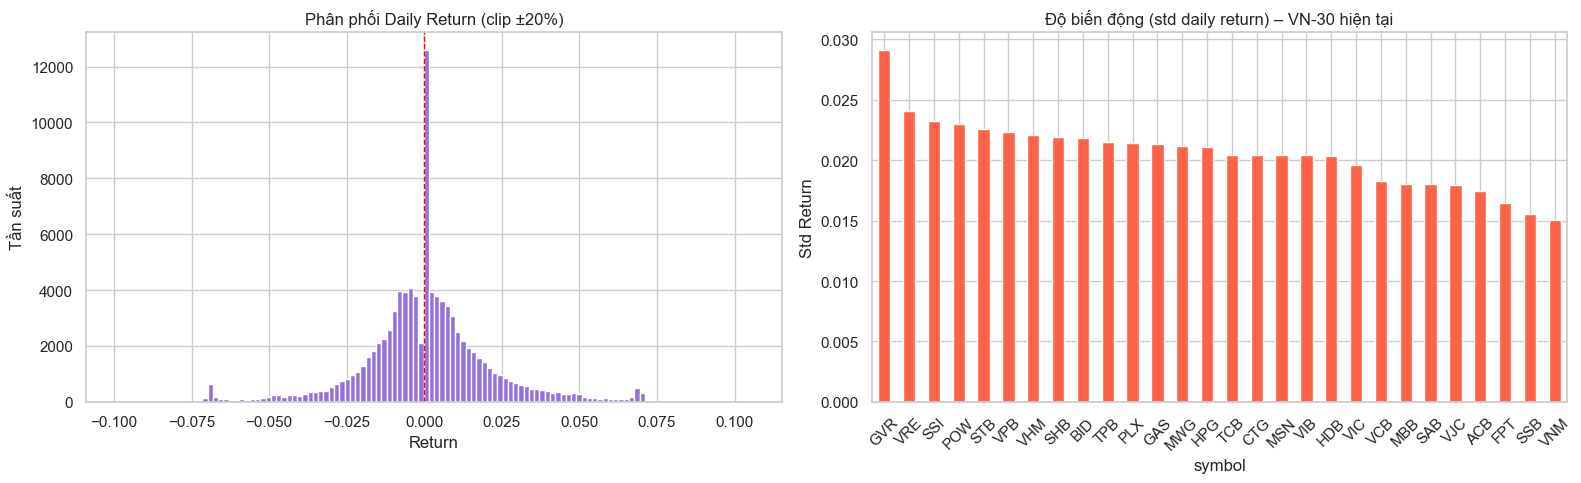

In [10]:
# Tính daily return theo từng mã
df = df.sort_values(['symbol', 'date'])
df['daily_return'] = df.groupby('symbol')['close'].pct_change()

# Phân phối return
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].hist(df['daily_return'].dropna().clip(-0.2, 0.2), bins=120, color='mediumpurple', edgecolor='white')
axes[0].set_title('Phân phối Daily Return (clip ±20%)')
axes[0].set_xlabel('Return')
axes[0].set_ylabel('Tần suất')
axes[0].axvline(0, color='red', linestyle='--', linewidth=1)

# Volatility (std return 30 ngày) theo từng mã hiện tại
vol_30d = (
    df[df['symbol'].isin(current_symbols)]
    .groupby('symbol')['daily_return']
    .std()
    .sort_values(ascending=False)
)
vol_30d.plot(kind='bar', ax=axes[1], color='tomato')
axes[1].set_title('Độ biến động (std daily return) – VN-30 hiện tại')
axes[1].set_ylabel('Std Return')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 8. Ma trận tương quan giá đóng cửa (VN-30 hiện tại)

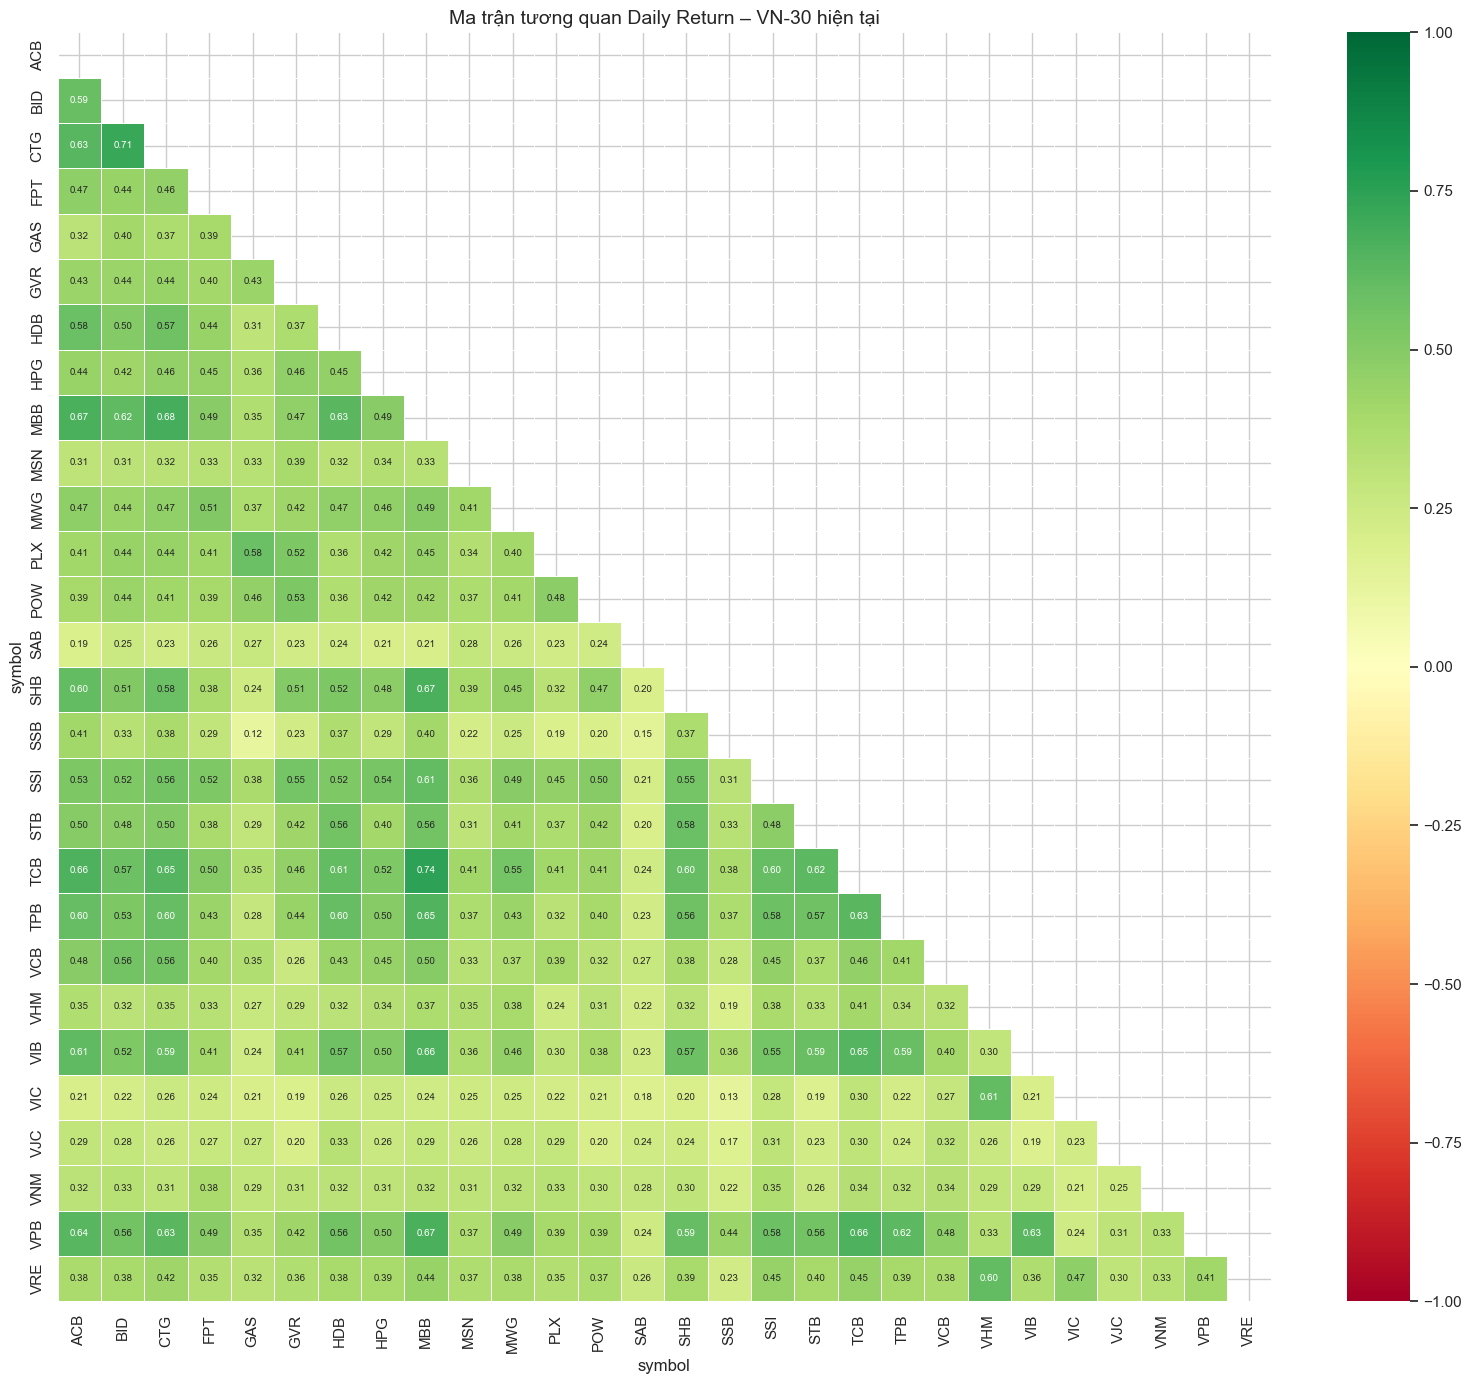

In [11]:
return_pivot = (
    df[df['symbol'].isin(current_symbols)]
    .pivot_table(index='date', columns='symbol', values='daily_return')
)
corr = return_pivot.corr()

fig, ax = plt.subplots(figsize=(16, 14))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
    center=0, vmin=-1, vmax=1, linewidths=0.4,
    annot_kws={'size': 7}, ax=ax
)
ax.set_title('Ma trận tương quan Daily Return – VN-30 hiện tại', fontsize=14)
plt.tight_layout()
plt.show()

## 9. Phân tích Volume vs Price Change

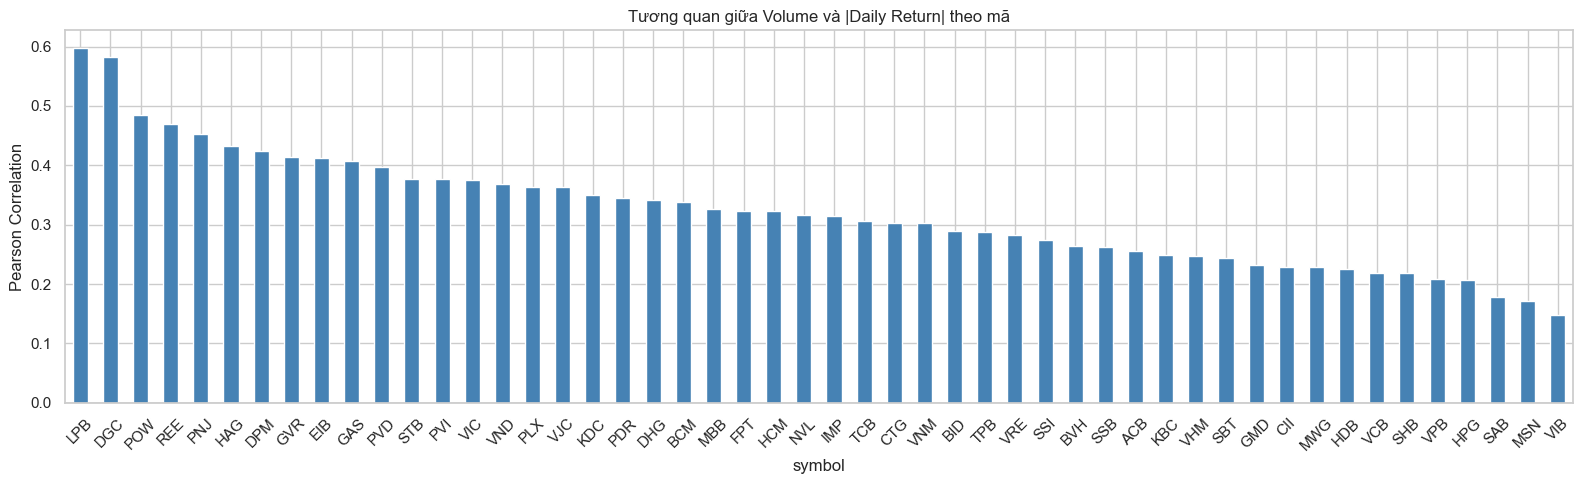

Tương quan trung bình: 0.3223


In [12]:
# Tương quan giữa volume và |daily_return| theo mã
corr_vol_ret = (
    df.dropna(subset=['daily_return', 'volume'])
    .groupby('symbol')
    .apply(lambda g: g['volume'].corr(g['daily_return'].abs()), include_groups=False)
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(16, 5))
corr_vol_ret.plot(kind='bar', ax=ax, color=corr_vol_ret.map(lambda x: 'steelblue' if x >= 0 else 'salmon'))
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Tương quan giữa Volume và |Daily Return| theo mã')
ax.set_ylabel('Pearson Correlation')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

print('Tương quan trung bình:', corr_vol_ret.mean().round(4))

## 10. Candlestick chart mẫu (1 mã)

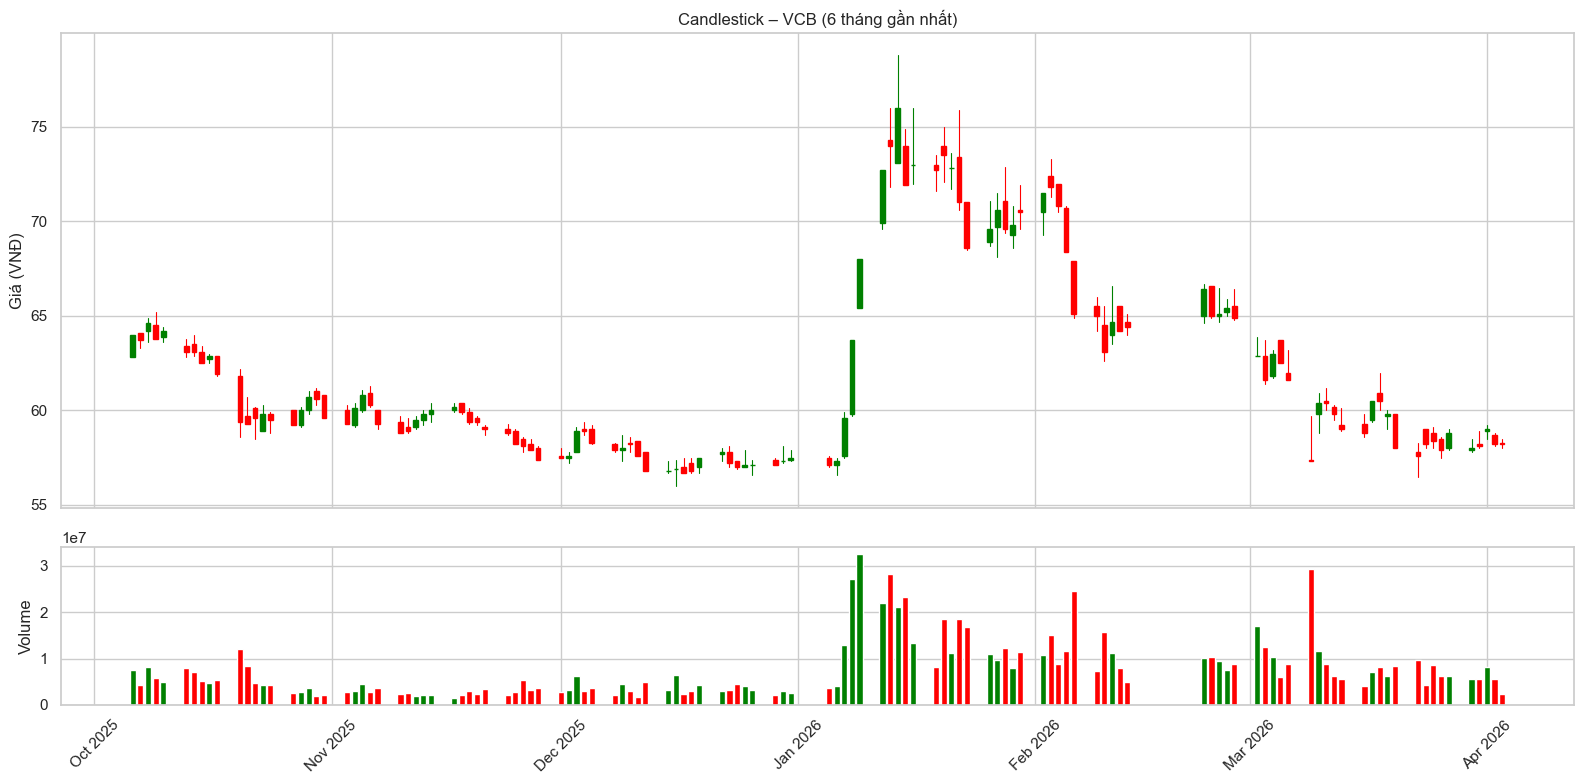

In [13]:
# Vẽ candlestick đơn giản cho VCB trong 6 tháng gần nhất
SAMPLE_SYMBOL = 'VCB'
cutoff = df['date'].max() - pd.Timedelta(days=180)
sample = df[(df['symbol'] == SAMPLE_SYMBOL) & (df['date'] >= cutoff)].copy()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 8), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)

# Giá
for _, row in sample.iterrows():
    color = 'green' if row['close'] >= row['open'] else 'red'
    ax1.plot([row['date'], row['date']], [row['low'], row['high']], color=color, linewidth=0.8)
    ax1.add_patch(plt.Rectangle(
        (mdates.date2num(row['date']) - 0.3, min(row['open'], row['close'])),
        0.6, abs(row['close'] - row['open']),
        color=color, zorder=2
    ))
ax1.set_title(f'Candlestick – {SAMPLE_SYMBOL} (6 tháng gần nhất)')
ax1.set_ylabel('Giá (VNĐ)')
ax1.xaxis_date()

# Volume
colors = ['green' if c >= o else 'red' for c, o in zip(sample['close'], sample['open'])]
ax2.bar(sample['date'], sample['volume'], color=colors, width=0.8)
ax2.set_ylabel('Volume')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.show()

## 11. Tóm tắt

In [14]:
summary = pd.DataFrame({
    'Tổng số dòng': [len(df)],
    'Số mã': [df['symbol'].nunique()],
    'Ngày đầu': [df['date'].min().date()],
    'Ngày cuối': [df['date'].max().date()],
    'Avg Close': [df['close'].mean().round(2)],
    'Avg Volume': [df['volume'].mean().round(0)],
    'Avg Daily Return': [df['daily_return'].mean().round(6)],
    'Std Daily Return': [df['daily_return'].std().round(6)],
})
summary.T.rename(columns={0: 'Giá trị'})

,Giá trị
Tổng số dòng,96849
Số mã,50
Ngày đầu,2012-02-06
Ngày cuối,2026-04-03
Avg Close,29.79
Avg Volume,"4,237,892.00"
Avg Daily Return,0.00
Std Daily Return,0.02
